## 과제 목표
PyTorch를 사용하여 1-Hidden Layer 인공신경망의 순전파(Forward Propagation)와 역전파(Backpropagation)를 구현합니다.

실제 차량 동역학 센서 데이터(가속도, 자이로스코프)를 4가지 주행 상태(급가속, 우회전, 좌회전, 급제동)로 분류하는 모델을 학습시킵니다.

**[구현 내용]**
- `torch.nn.Module`을 사용한 네트워크 정의
- PyTorch의 자동 미분(autograd)을 통한 역전파
- `torch.optim`을 사용한 가중치 업데이트

In [1]:
!curl -L -o driving-behavior-dataset.zip\
  https://www.kaggle.com/api/v1/datasets/download/shashwatwork/driving-behavior-dataset

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 6790k  100 6790k    0     0  16.6M      0 --:--:-- --:--:-- --:--:-- 16.6M


In [2]:
import zipfile
with zipfile.ZipFile('driving-behavior-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('driving-behavior-dataset')

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# ---------------------------------------------------------
# 1. 실제 차량 동역학 센서 데이터 (sensor_raw.csv) 로드
# ---------------------------------------------------------
def load_sensor_raw_data(csv_path='sensor_raw.csv', test_ratio=0.2):
    """
    가속도(AccX, AccY, AccZ) 및 자이로스코프(GyroX, GyroY, GyroZ) Raw 데이터를 로드합니다.
    클래스: 1(급가속), 2(우회전), 3(좌회전), 4(급제동)
    """
    try:
        df = pd.read_csv(csv_path)
    except FileNotFoundError:
        raise FileNotFoundError(f"'{csv_path}' 파일을 찾을 수 없습니다. 경로를 확인하세요.")

    df = df.dropna()

    feature_cols = df.columns[1:]
    label_col = df.columns[0]

    X = df[feature_cols].values
    Y = df[label_col].values.astype(int) - 1

    np.random.seed(42)
    indices = np.arange(len(X))
    np.random.shuffle(indices)
    X = X[indices]
    Y = Y[indices]

    split_idx = int(len(X) * (1 - test_ratio))
    X_train, X_test = X[:split_idx], X[split_idx:]
    Y_train, Y_test = Y[:split_idx], Y[split_idx:]

    mean_X = X_train.mean(axis=0)
    std_X  = X_train.std(axis=0)
    std_X[std_X == 0] = 1e-8

    X_train = (X_train - mean_X) / std_X
    X_test  = (X_test  - mean_X) / std_X

    return X_train, Y_train, X_test, Y_test

X_train_np, Y_train_np, X_test_np, Y_test_np = load_sensor_raw_data(
    'driving-behavior-dataset/sensor_raw.csv'
)

output_size = 4
print(f"Train Features Shape: {X_train_np.shape}")
print(f"Test  Features Shape: {X_test_np.shape}")

unique, counts = np.unique(Y_train_np, return_counts=True)
class_names = ['Accel (0)', 'Right (1)', 'Left (2)', 'Brake (3)']
distribution = {class_names[k]: v for k, v in zip(unique, counts)}
print(f"\nClass Distribution (Train): {distribution}")

Train Features Shape: (891, 6)
Test  Features Shape: (223, 6)

Class Distribution (Train): {'Accel (0)': np.int64(209), 'Right (1)': np.int64(237), 'Left (2)': np.int64(269), 'Brake (3)': np.int64(176)}


### 1. PyTorch Tensor 변환 및 DataLoader 구성
NumPy 배열을 PyTorch Tensor로 변환하고, 미니배치 학습을 위해 `DataLoader`를 구성합니다.

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# NumPy → PyTorch Tensor 변환
X_train_t = torch.tensor(X_train_np, dtype=torch.float32).to(device)
Y_train_t = torch.tensor(Y_train_np, dtype=torch.long).to(device)
X_test_t  = torch.tensor(X_test_np,  dtype=torch.float32).to(device)
Y_test_t  = torch.tensor(Y_test_np,  dtype=torch.long).to(device)

# DataLoader (미니배치 없이 전체 배치 사용 — 원본과 동일 조건)
train_dataset = TensorDataset(X_train_t, Y_train_t)
train_loader  = DataLoader(train_dataset, batch_size=len(X_train_t), shuffle=False)

Using device: cpu


### 2. 네트워크 정의 (torch.nn.Module)
`nn.Linear`와 `nn.ReLU`를 사용하여 1-Hidden Layer MLP를 정의합니다.

아키텍처: **Input(6) → Linear → ReLU → Linear → Softmax**

> `nn.CrossEntropyLoss`는 내부적으로 Softmax + NLL Loss를 결합하므로, 출력층에 Softmax를 별도로 추가하지 않습니다.

In [5]:
input_size  = X_train_np.shape[1]  # 6
hidden_size = 16

class OneHiddenLayerNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)   # W1, b1
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)  # W2, b2

        # 원본과 동일한 초기화 (작은 랜덤값, 편향=0)
        nn.init.normal_(self.fc1.weight, mean=0.0, std=0.01)
        nn.init.zeros_(self.fc1.bias)
        nn.init.normal_(self.fc2.weight, mean=0.0, std=0.01)
        nn.init.zeros_(self.fc2.bias)

    def forward(self, x):
        x = self.fc1(x)   # Z1 = x @ W1.T + b1
        x = self.relu(x)  # A1 = ReLU(Z1)
        x = self.fc2(x)   # Z2 = A1 @ W2.T + b2  (logits)
        return x

model = OneHiddenLayerNet(input_size, hidden_size, output_size).to(device)
print(model)

OneHiddenLayerNet(
  (fc1): Linear(in_features=6, out_features=16, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=16, out_features=4, bias=True)
)


### 3. 모델 학습 루프 (Training Loop)
- **손실 함수**: `nn.CrossEntropyLoss` (Softmax + NLLLoss)
- **옵티마이저**: SGD (learning_rate=0.1, 원본과 동일)
- **역전파**: `loss.backward()` → PyTorch autograd가 자동으로 그래디언트 계산

Epoch [50/5000], Loss: 0.6254
Epoch [100/5000], Loss: 0.6254
Epoch [150/5000], Loss: 0.6253
Epoch [200/5000], Loss: 0.6252
Epoch [250/5000], Loss: 0.6252
Epoch [300/5000], Loss: 0.6251
Epoch [350/5000], Loss: 0.6250
Epoch [400/5000], Loss: 0.6249
Epoch [450/5000], Loss: 0.6249
Epoch [500/5000], Loss: 0.6248
Epoch [550/5000], Loss: 0.6247
Epoch [600/5000], Loss: 0.6246
Epoch [650/5000], Loss: 0.6246
Epoch [700/5000], Loss: 0.6245
Epoch [750/5000], Loss: 0.6244
Epoch [800/5000], Loss: 0.6242
Epoch [850/5000], Loss: 0.6240
Epoch [900/5000], Loss: 0.6238
Epoch [950/5000], Loss: 0.6237
Epoch [1000/5000], Loss: 0.6236
Epoch [1050/5000], Loss: 0.6235
Epoch [1100/5000], Loss: 0.6233
Epoch [1150/5000], Loss: 0.6232
Epoch [1200/5000], Loss: 0.6231
Epoch [1250/5000], Loss: 0.6230
Epoch [1300/5000], Loss: 0.6229
Epoch [1350/5000], Loss: 0.6229
Epoch [1400/5000], Loss: 0.6228
Epoch [1450/5000], Loss: 0.6227
Epoch [1500/5000], Loss: 0.6227
Epoch [1550/5000], Loss: 0.6226
Epoch [1600/5000], Loss: 0.6

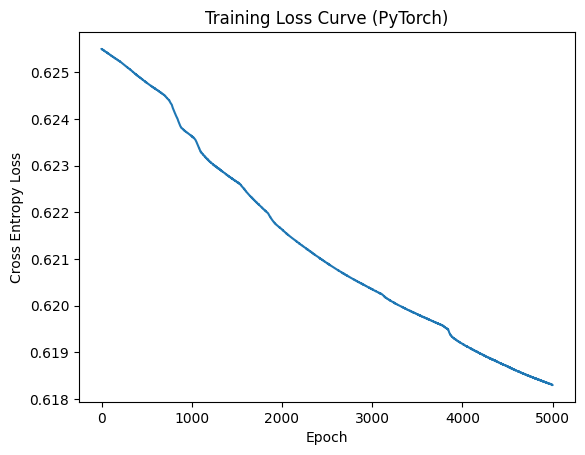

In [11]:
epochs        = 5000
learning_rate = 0.1

criterion = nn.CrossEntropyLoss()                          # Softmax + NLL
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

losses = []

model.train()
for epoch in range(epochs):
    for X_batch, Y_batch in train_loader:
        # ---- 순전파 (Forward) ----
        logits = model(X_batch)             # (N, 4) 로짓

        # ---- 손실 계산 ----
        loss = criterion(logits, Y_batch)   # CrossEntropyLoss: Softmax → NLLLoss

        # ---- 역전파 (Backward) ----
        optimizer.zero_grad()  # 이전 그래디언트 초기화
        loss.backward()        # autograd로 그래디언트 계산

        # ---- 가중치 업데이트 (Gradient Descent) ----
        optimizer.step()

    losses.append(loss.item())

    if (epoch + 1) % 50 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

# 학습 곡선 시각화
plt.plot(losses)
plt.title('Training Loss Curve (PyTorch)')
plt.xlabel('Epoch')
plt.ylabel('Cross Entropy Loss')
plt.show()

### 4. 평가 및 시각화 (Evaluation & Visualization)
학습이 끝난 모델로 테스트 데이터를 추론하고 정확도를 측정합니다.
PCA로 6차원 특징을 2차원으로 축소하여 예측 결과를 시각화합니다.

Overall Accuracy: 68.61%

PCA Explained Variance Ratio: PC1(0.44), PC2(0.18)


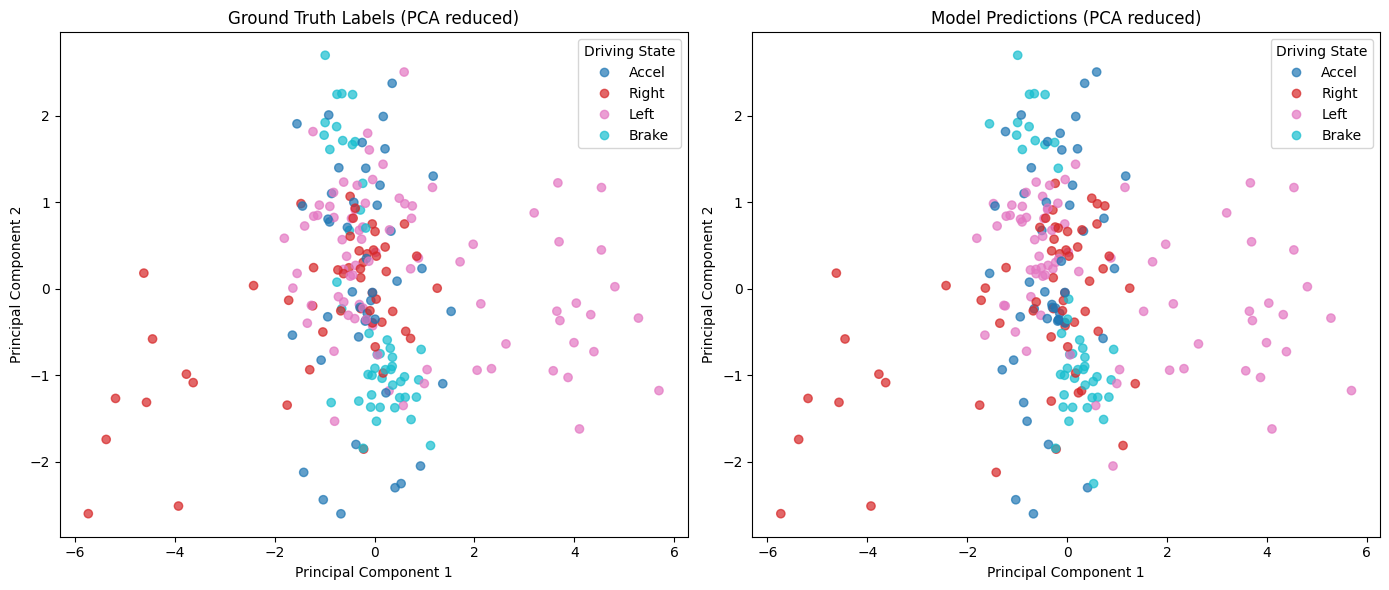

In [12]:
from sklearn.decomposition import PCA

# ---------------------------------------------------------
# 1. 모델 추론 (Test 데이터)
# ---------------------------------------------------------
model.eval()
with torch.no_grad():
    logits_test   = model(X_test_t)                       # (N, 4)
    predictions_t = torch.argmax(logits_test, dim=1)      # 클래스 인덱스

predictions_np = predictions_t.cpu().numpy()
accuracy = np.mean(predictions_np == Y_test_np)
print(f'Overall Accuracy: {accuracy * 100:.2f}%\n')

# ---------------------------------------------------------
# 2. 결과 시각화 (PCA 2D 축소)
# ---------------------------------------------------------
pca = PCA(n_components=2)
X_test_2d = pca.fit_transform(X_test_np)

explained_variance = pca.explained_variance_ratio_
print(f"PCA Explained Variance Ratio: PC1({explained_variance[0]:.2f}), PC2({explained_variance[1]:.2f})")

plt.figure(figsize=(14, 6))
class_labels = ['Accel', 'Right', 'Left', 'Brake']

# 왼쪽: Ground Truth
plt.subplot(1, 2, 1)
scatter1 = plt.scatter(X_test_2d[:, 0], X_test_2d[:, 1],
                       c=Y_test_np, cmap='tab10', alpha=0.7)
plt.title('Ground Truth Labels (PCA reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(handles=scatter1.legend_elements()[0], labels=class_labels, title='Driving State')

# 오른쪽: Model Predictions
plt.subplot(1, 2, 2)
scatter2 = plt.scatter(X_test_2d[:, 0], X_test_2d[:, 1],
                       c=predictions_np, cmap='tab10', alpha=0.7)
plt.title('Model Predictions (PCA reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(handles=scatter2.legend_elements()[0], labels=class_labels, title='Driving State')

plt.tight_layout()
plt.show()